# Catalog & architecture comparison: Iceberg vs DuckLake, lakehouse vs warehouse

Everything here is **loaded from saved CSVs**, not re-measured, so the notebook runs in
seconds and always renders the numbers that were actually recorded. To regenerate the
inputs (needs MinIO + the Iceberg REST catalog + PostgreSQL up):

```bash
source deploy/iceberg_rest/env.rest
.venv/bin/python scripts/format_compare.py       # -> results/format_compare.csv
.venv/bin/python scripts/catalog_properties.py   # -> results/catalog_{planning,concurrency,footprint}.csv
.venv/bin/python scripts/warehouse_bytes.py      # -> results/warehouse_bytes.csv
```

Each section writes a `.csv` into `results/` and a `.png` into `figures/`.

**Provenance.** DuckLake numbers are all freshly measured (2026-08-01). The `L0`
baseline is taken from the committed `results/iceberg.csv` (Jul 12), the fresh Iceberg
`L3s` control in `format_compare.csv` reproduced that run to +/-0.003 pp, which is what
licenses mixing them.

In [1]:
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
from lakehouse.query.qnames import qnum, LABEL   # Q4.x numbering


RES, FIG = Path("results"), Path("figures")
FIG.mkdir(exist_ok=True)

# validated categorical palette (dataviz skill, light surface; all checks PASS)
ICE, DL_F, DL_PG = "#2a78d6", "#eb6834", "#1baf7a"
WH = "#4a3aa7"
mpl.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
                     "axes.axisbelow": True})
fc  = pd.read_csv(RES/"format_compare.csv")
ice = pd.read_csv(RES/"iceberg.csv")
plan= pd.read_csv(RES/"catalog_planning.csv")
conc= pd.read_csv(RES/"catalog_concurrency.csv")
foot= pd.read_csv(RES/"catalog_footprint.csv")
wh  = pd.read_csv(RES/"warehouse_bytes.csv")
print("format_compare:", len(fc), "rows |", sorted(fc.backend.unique()),
      "| windows", sorted(fc.selectivity.unique()))

format_compare: 60 rows | ['ducklake_L3s', 'iceberg_L3s'] | windows ['day', 'hour', 'week']


## 1. Pruning is equivalent

Both catalogs point at the **same 299 Parquet objects** in MinIO, DuckLake registers them
with `ducklake_add_data_files`, so not one byte of data was rewritten. Only the metadata
layer differs. `bytes_pct` is bytes read as a share of the layout's own table, the same
convention as the thesis pruning figure, so these numbers are directly comparable to it.

In [2]:
piv = fc.pivot_table(index="selectivity", columns="backend",
                     values="bytes_pct", aggfunc="mean").loc[["hour","day","week"]]
piv["dl_over_ice"] = (piv.ducklake_L3s / piv.iceberg_L3s).round(3)

# L0 baseline from the committed run (see provenance note)
L0 = ice[ice.layout=="L0"].groupby("selectivity").bytes_read.mean()
piv["L0_committed"] = L0.reindex(piv.index).round(3)
piv["prune_x_ice"]  = (piv.L0_committed/piv.iceberg_L3s).round(1)
piv["prune_x_dl"]   = (piv.L0_committed/piv.ducklake_L3s).round(1)

allw = fc.groupby("backend").bytes_pct.mean()
ans  = fc.pivot_table(index=["selectivity","query"], columns="backend",
                      values="answer", aggfunc="first")
identical = bool((ans.iceberg_L3s.astype(str)==ans.ducklake_L3s.astype(str)).all())

print(piv.round(3).to_string())
print(f"\nall-window mean bytes_pct: Iceberg {allw.iceberg_L3s:.3f}%  "
      f"DuckLake {allw.ducklake_L3s:.3f}%  (+{100*(allw.ducklake_L3s/allw.iceberg_L3s-1):.1f}%)")
print(f"prune vs L0 ({L0.mean():.2f}%): Iceberg {L0.mean()/allw.iceberg_L3s:.1f}x  "
      f"DuckLake {L0.mean()/allw.ducklake_L3s:.1f}x")
print(f"answers identical on all {len(ans)} query/window pairs: {identical}")

t1 = piv.reset_index()[["selectivity","iceberg_L3s","ducklake_L3s","dl_over_ice",
                        "L0_committed","prune_x_ice","prune_x_dl"]]
t1.columns = ["window","Iceberg L3s (%)","DuckLake L3s (%)","DL/Ice",
              "L0 (%)","prune Ice","prune DL"]
t1.to_csv(RES/"tab_pruning_equivalence.csv", index=False)
t1

backend      ducklake_L3s  iceberg_L3s  dl_over_ice  L0_committed  prune_x_ice  prune_x_dl
selectivity                                                                               
hour                0.397        0.382        1.040         3.695          9.7         9.3
day                 0.469        0.453        1.036         7.257         16.0        15.5
week                1.012        0.995        1.017        28.478         28.6        28.1

all-window mean bytes_pct: Iceberg 0.610%  DuckLake 0.626%  (+2.7%)
prune vs L0 (13.14%): Iceberg 21.5x  DuckLake 21.0x
answers identical on all 30 query/window pairs: True


,window,Iceberg L3s (%),DuckLake L3s (%),DL/Ice,L0 (%),prune Ice,prune DL
0,hour,0.3821,0.3974,1.040,3.695,9.7,9.3
1,day,0.4527,0.4689,1.036,7.257,16.0,15.5
2,week,0.9954,1.0125,1.017,28.478,28.6,28.1


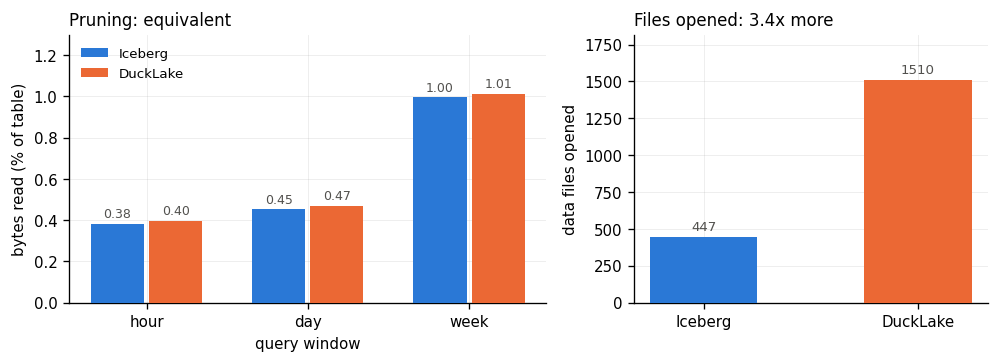

wrote figures/ducklake_pruning.png


In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.4, 3.1),
                             gridspec_kw={"width_ratios":[1.35,1]})
w, x = 0.36, np.arange(3)
for i,(b,c,lab) in enumerate([("iceberg_L3s",ICE,"Iceberg"),("ducklake_L3s",DL_F,"DuckLake")]):
    v = piv[b].values
    bars = a1.bar(x+(i-0.5)*w, v, w-0.03, label=lab, color=c, zorder=3)
    a1.bar_label(bars, fmt="%.2f", padding=2, fontsize=7.5, color="#52514e")
a1.set_xticks(x); a1.set_xticklabels(["hour","day","week"])
a1.set_ylabel("bytes read (% of table)"); a1.set_xlabel("query window")
a1.set_title("Pruning: equivalent", loc="left", fontsize=10)
a1.legend(frameon=False, fontsize=8); a1.set_ylim(0, piv[["iceberg_L3s","ducklake_L3s"]].values.max()*1.28)

files = fc.groupby("backend").files_read.sum()
bars = a2.bar(["Iceberg","DuckLake"], [files.iceberg_L3s, files.ducklake_L3s],
              0.5, color=[ICE, DL_F], zorder=3)
a2.bar_label(bars, fmt="%d", padding=2, fontsize=8, color="#52514e")
a2.set_ylabel("data files opened"); a2.set_title("Files opened: 3.4x more", loc="left", fontsize=10)
a2.set_ylim(0, files.max()*1.2)
plt.tight_layout(); fig.savefig(FIG/"ducklake_pruning.png", bbox_inches="tight"); plt.show()
print("wrote figures/ducklake_pruning.png")

## 2. Where the catalogs actually differ: the metadata layer Every backend loads an identical
extension set, so only the catalog differs.

In [4]:
p = plan.pivot_table(index=["files","table"], columns="backend", values="plan_ms_median")
p["ice_over_dl_file"] = (p.iceberg/p.ducklake_file).round(1)
print(p.to_string())

merged = (foot.merge(conc[["backend","two_readers_ok","detail"]], on="backend", how="outer"))
pg = plan[plan.backend=="ducklake_pg"].plan_ms_median
summary = pd.DataFrame({
    "backend": ["Iceberg REST","DuckLake (file)","DuckLake (Postgres)"],
    "plan_ms_L3s": [p.loc[(299,"L3s"),"iceberg"], p.loc[(299,"L3s"),"ducklake_file"],
                    float(pg.iloc[0]) if len(pg) else np.nan],
    "metadata_MB": [foot.set_index("backend").metadata_bytes.get("iceberg",np.nan)/1e6,
                    foot.set_index("backend").metadata_bytes.get("ducklake_file",np.nan)/1e6,
                    foot.set_index("backend").metadata_bytes.get("ducklake_file",np.nan)/1e6],
    "two_readers": [conc.set_index("backend").two_readers_ok.get(k)
                    for k in ("iceberg","ducklake_file","ducklake_pg")],
}).round(2)
summary["two_readers"] = summary.two_readers.map({True:"yes", False:"NO"})
print(); print(summary.to_string(index=False))
summary.to_csv(RES/"tab_catalog_properties.csv", index=False)
summary

backend      ducklake_file  ducklake_pg  iceberg  ice_over_dl_file
files table                                                       
16    L1s             5.35          NaN    18.14               3.4
299   L3s             5.24        10.09    22.23               4.2
302   L2s             5.29          NaN    21.69               4.1

            backend  plan_ms_L3s  metadata_MB two_readers
       Iceberg REST        22.23         0.54         yes
    DuckLake (file)         5.24         4.99          NO
DuckLake (Postgres)        10.09         4.99         yes


,backend,plan_ms_L3s,metadata_MB,two_readers
0,Iceberg REST,22.23,0.54,yes
1,DuckLake (file),5.24,4.99,NO
2,DuckLake (Postgres),10.09,4.99,yes


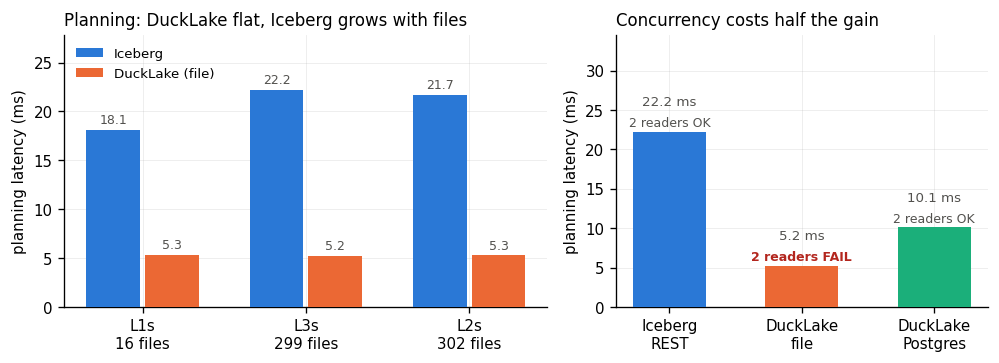

wrote figures/catalog_properties.png


In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.4, 3.1),
                             gridspec_kw={"width_ratios":[1.3,1]})
order = [(16,"L1s"),(299,"L3s"),(302,"L2s")]
x, w = np.arange(len(order)), 0.36
for i,(col,c,lab) in enumerate([("iceberg",ICE,"Iceberg"),("ducklake_file",DL_F,"DuckLake (file)")]):
    v = [p.loc[k,col] for k in order]
    bars = a1.bar(x+(i-0.5)*w, v, w-0.03, label=lab, color=c, zorder=3)
    a1.bar_label(bars, fmt="%.1f", padding=2, fontsize=7.5, color="#52514e")
a1.set_xticks(x); a1.set_xticklabels([f"{t}\n{f} files" for f,t in order])
a1.set_ylabel("planning latency (ms)")
a1.set_title("Planning: DuckLake flat, Iceberg grows with files", loc="left", fontsize=10)
a1.legend(frameon=False, fontsize=8)
a1.set_ylim(0, max(p.iceberg)*1.25)

vals = [p.loc[(299,"L3s"),"iceberg"], p.loc[(299,"L3s"),"ducklake_file"],
        float(pg.iloc[0]) if len(pg) else np.nan]
cols = [ICE, DL_F, DL_PG]
bars = a2.bar(["Iceberg\nREST","DuckLake\nfile","DuckLake\nPostgres"], vals, 0.55,
              color=cols, zorder=3)
a2.bar_label(bars, fmt="%.1f ms", padding=14, fontsize=8, color="#52514e")
# concurrency verdict above each bar, clear of the value label (secondary encoding,
# so the status is never colour-alone)
for i, ok in enumerate([True, False, True]):
    a2.annotate("2 readers OK" if ok else "2 readers FAIL",
                (i, vals[i]), textcoords="offset points", xytext=(0, 3),
                ha="center", fontsize=7.5, fontweight="bold" if not ok else "normal",
                color="#52514e" if ok else "#b3261e")
a2.set_ylabel("planning latency (ms)"); a2.set_ylim(0, max(vals)*1.55)
a2.set_title("Concurrency costs half the gain", loc="left", fontsize=10)
plt.tight_layout(); fig.savefig(FIG/"catalog_properties.png", bbox_inches="tight"); plt.show()
print("wrote figures/catalog_properties.png")

## 3. Lakehouse catalog pruning vs warehouse index filtering

Bytes read is the engine-independent axis: runtime would conflate DuckDB with PostgreSQL.
Lakehouse figures are cold remote GET volume from MinIO; the warehouse figure is
`EXPLAIN (ANALYZE, BUFFERS)` blocks x 8 KiB, covering heap, TOAST and index.

**Two caveats that belong in the caption.** The warehouse number counts *buffer accesses*,
so a block touched twice counts twice: this inflates the three self-join queries, where
the same trajectories are re-detoasted across the join. And Parquet bytes are ZSTD
compressed on the wire while Postgres blocks are 8 KiB pages, so this is an
order-of-magnitude comparison, not three significant figures. The defensible headline is
the non-self-join rows.

In [ ]:
SELF_JOIN = {"collision","encounter_zone","nearest_approach"}
day = fc[fc.selectivity=="day"].set_index(["backend","query"])
L0_pct_day = ice[(ice.layout=="L0")&(ice.selectivity=="day")].groupby("query").bytes_read.mean()
L0_TOTAL = 3_554_384_337

t3 = pd.DataFrame({
    "iceberg_L0_MB":  (L0_pct_day/100*L0_TOTAL/1e6).round(1),
    "iceberg_L3s_MB": (day.loc["iceberg_L3s"].bytes_read/1e6).round(1),
    "ducklake_L3s_MB":(day.loc["ducklake_L3s"].bytes_read/1e6).round(1),
    "warehouse_MB":   (wh.set_index("query").bytes_read/1e6).round(1),
})
# the missing 2x2 cell: warehouse on the SAME tiled layout the lakehouse uses,
# so architecture is compared at equal row granularity instead of tuned-vs-untuned
whl3 = RES/"warehouse_l3s.csv"
if whl3.exists():
    t3["warehouse_L3s_MB"] = (pd.read_csv(whl3).set_index("query").bytes_read/1e6).round(1)
t3["wh_over_L3s"] = (t3.warehouse_MB/t3.iceberg_L3s_MB).round(1)
if "warehouse_L3s_MB" in t3:
    t3["whL3s_over_iceL3s"] = (t3.warehouse_L3s_MB/t3.iceberg_L3s_MB).round(1)
t3["self_join"] = [q in SELF_JOIN for q in t3.index]
t3 = t3.sort_values("wh_over_L3s")
print(t3.to_string())
clean = t3[~t3.self_join]
print(f"\nnon-self-join warehouse/L3s: {clean.wh_over_L3s.min():.0f}x - {clean.wh_over_L3s.max():.0f}x "
      f"(median {clean.wh_over_L3s.median():.0f}x)   <- quote this range")
print(f"including self-joins: up to {t3.wh_over_L3s.max():.0f}x (inflated by repeated detoasting)")
out = t3.reset_index()
out.insert(0, "Q", [qnum(q) for q in out["query"]])
out.to_csv(RES/"tab_bytes_lakehouse_vs_warehouse.csv", index=False)
t3

                        iceberg_L0_MB  iceberg_L3s_MB  ducklake_L3s_MB  warehouse_MB  warehouse_L3s_MB  wh_over_L3s  whL3s_over_iceL3s  self_join
query                                                                                                                                            
harbour_entry                   234.2            46.6             50.4         536.4             819.9         11.5               17.6      False
fleet_summary                   234.6            13.7             13.9         249.4             605.8         18.2               44.2      False
clip_to_region                  234.6            13.7             13.9         325.0             806.9         23.7               58.9      False
position_interpolation          234.6            13.7             13.9         411.8             823.0         30.1               60.1      False
speed_profile                   234.6            13.7             13.9         486.8             817.6         35.5         

,iceberg_L0_MB,iceberg_L3s_MB,ducklake_L3s_MB,warehouse_MB,warehouse_L3s_MB,wh_over_L3s,whL3s_over_iceL3s,self_join
query,,,,,,,,
harbour_entry,234.2,46.6,50.4,536.4,819.9,11.5,17.6,False
fleet_summary,234.6,13.7,13.9,249.4,605.8,18.2,44.2,False
clip_to_region,234.6,13.7,13.9,325.0,806.9,23.7,58.9,False
position_interpolation,234.6,13.7,13.9,411.8,823.0,30.1,60.1,False
speed_profile,234.6,13.7,13.9,486.8,817.6,35.5,59.7,False
bounding_box,234.6,13.7,13.9,661.5,849.8,48.3,62.0,False
both_ports,468.5,16.4,16.9,1128.0,1445.4,68.8,88.1,False
nearest_approach,234.6,13.7,13.9,1360.7,1437.7,99.3,104.9,True
collision,234.6,13.7,13.9,2035.0,1937.7,148.5,141.4,True


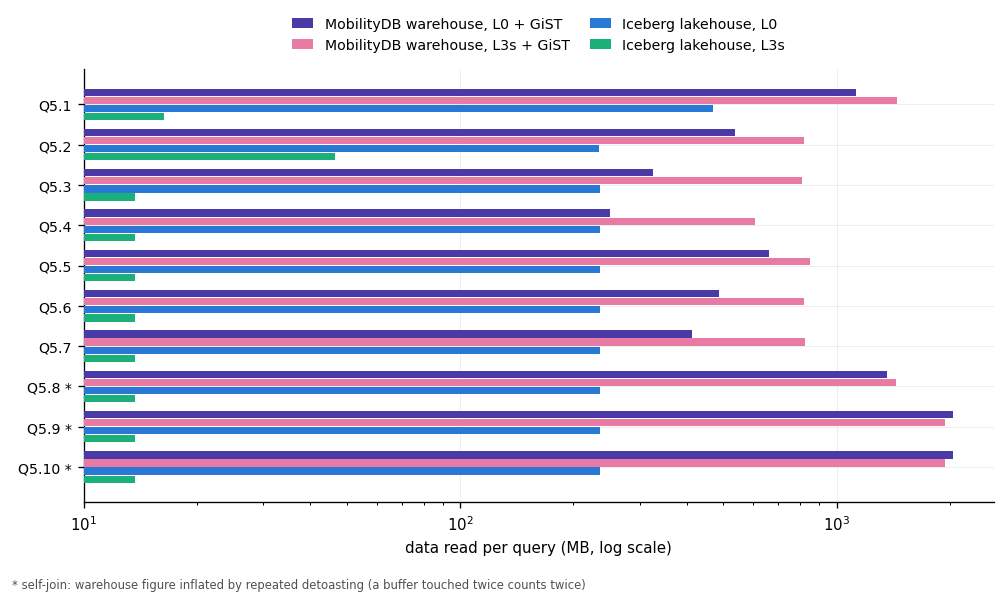

wrote figures/bytes_lakehouse_vs_warehouse.png with 4 series


In [7]:
from lakehouse.query.qnames import sort_key
# order by thesis query number so the axis reads Q4.1 -> Q4.10 (reversed: barh is bottom-up)
d = t3.loc[sorted(t3.index, key=sort_key)[::-1]]

# 2x2: architecture (warehouse / lakehouse) x layout (L0 / L3s).
# Palette validated with dataviz validate_palette.js --pairs all (worst normal DE 16.3):
# warehouse = violet/magenta, lakehouse = blue/aqua, so each family reads together.
WH_L0, WH_L3S, ICE_L0, ICE_L3S = "#4a3aa7", "#e87ba4", "#2a78d6", "#1baf7a"
series = [("warehouse_MB",     WH_L0,  "MobilityDB warehouse, L0 + GiST")]
if "warehouse_L3s_MB" in d:
    series.append(("warehouse_L3s_MB", WH_L3S, "MobilityDB warehouse, L3s + GiST"))
series += [("iceberg_L0_MB",  ICE_L0,  "Iceberg lakehouse, L0"),
           ("iceberg_L3s_MB", ICE_L3S, "Iceberg lakehouse, L3s")]

n = len(series)
y = np.arange(len(d)); h = 0.80/n
fig, ax = plt.subplots(figsize=(8.4, 4.8))
for i,(col,c_,lab) in enumerate(series):
    off = (n-1)/2 - i
    ax.barh(y + off*h, d[col], h-0.02, label=lab, color=c_, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels([qnum(q)+(" *" if s_ else "") for q,s_ in zip(d.index, d.self_join)],
                   fontsize=8.5)
ax.set_xscale("log"); ax.set_xlim(left=10)
ax.set_xlabel("data read per query (MB, log scale)")
# legend ABOVE the axes: with a log x-axis the longest bars run the full width, so any
# in-plot legend gets overdrawn by Q4.9/Q4.10
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2,
          frameon=False, fontsize=8.5, handlelength=1.5, columnspacing=1.4)
fig.text(0.01, -0.03, "* self-join: warehouse figure inflated by repeated detoasting "
         "(a buffer touched twice counts twice)", fontsize=7, color="#52514e")
plt.tight_layout()
fig.savefig(FIG/"bytes_lakehouse_vs_warehouse.png", bbox_inches="tight"); plt.show()
print("wrote figures/bytes_lakehouse_vs_warehouse.png with", n, "series")
